# Notebook 4: Census Analysis & Retail Demand Index

### Objective

The objective of this notebook is to analyze India's Census data and transform demographic information into business-ready features that can be used for retail expansion analysis. District-level population, literacy, household count, and workforce statistics are processed to generate a Retail Demand Index (RDI), which estimates the market potential of each district.

The Retail Demand Index will later be combined with dark store locations, competition data, and accessibility features to build the final location recommendation engine.

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

plt.style.use("ggplot")

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving 2011-IndiaStateDist-0000.xlsx to 2011-IndiaStateDist-0000 (1).xlsx


In [ ]:
!pip install openpyxl
census = pd.read_excel("2011-IndiaStateDist-0000.xlsx")

In [ ]:
print("Rows    :", census.shape[0])
print("Columns :", census.shape[1])

Rows    : 2028
Columns : 94


In [ ]:
print("Rows :", census.shape[0])
print("Columns :", census.shape[1])

Rows : 2028
Columns : 94


In [ ]:
print(census.columns.tolist())

['State', 'District', 'Subdistt', 'Town/Village', 'Ward', 'EB', 'Level', 'Name', 'TRU', 'No_HH', 'TOT_P', 'TOT_M', 'TOT_F', 'P_06', 'M_06', 'F_06', 'P_SC', 'M_SC', 'F_SC', 'P_ST', 'M_ST', 'F_ST', 'P_LIT', 'M_LIT', 'F_LIT', 'P_ILL', 'M_ILL', 'F_ILL', 'TOT_WORK_P', 'TOT_WORK_M', 'TOT_WORK_F', 'MAINWORK_P', 'MAINWORK_M', 'MAINWORK_F', 'MAIN_CL_P', 'MAIN_CL_M', 'MAIN_CL_F', 'MAIN_AL_P', 'MAIN_AL_M', 'MAIN_AL_F', 'MAIN_HH_P', 'MAIN_HH_M', 'MAIN_HH_F', 'MAIN_OT_P', 'MAIN_OT_M', 'MAIN_OT_F', 'MARGWORK_P', 'MARGWORK_M', 'MARGWORK_F', 'MARG_CL_P', 'MARG_CL_M', 'MARG_CL_F', 'MARG_AL_P', 'MARG_AL_M', 'MARG_AL_F', 'MARG_HH_P', 'MARG_HH_M', 'MARG_HH_F', 'MARG_OT_P', 'MARG_OT_M', 'MARG_OT_F', 'MARGWORK_3_6_P', 'MARGWORK_3_6_M', 'MARGWORK_3_6_F', 'MARG_CL_3_6_P', 'MARG_CL_3_6_M', 'MARG_CL_3_6_F', 'MARG_AL_3_6_P', 'MARG_AL_3_6_M', 'MARG_AL_3_6_F', 'MARG_HH_3_6_P', 'MARG_HH_3_6_M', 'MARG_HH_3_6_F', 'MARG_OT_3_6_P', 'MARG_OT_3_6_M', 'MARG_OT_3_6_F', 'MARGWORK_0_3_P', 'MARGWORK_0_3_M', 'MARGWORK_0_3_F', 

In [ ]:
census.head()

,State,District,Subdistt,Town/Village,Ward,EB,Level,Name,TRU,No_HH,...,MARG_AL_0_3_F,MARG_HH_0_3_P,MARG_HH_0_3_M,MARG_HH_0_3_F,MARG_OT_0_3_P,MARG_OT_0_3_M,MARG_OT_0_3_F,NON_WORK_P,NON_WORK_M,NON_WORK_F
0,0,0,0,0,0,0,India,India,Total,249501663,...,5820403,1420348,491424,928924,5518450,3082613,2435837,728966109,291330383,437635726
1,0,0,0,0,0,0,India,India,Rural,168612897,...,5640822,1154975,386077,768898,3803400,1972348,1831052,485005760,200944045,284061715
2,0,0,0,0,0,0,India,India,Urban,80888766,...,179581,265373,105347,160026,1715050,1110265,604785,243960349,90386338,153574011
3,1,0,0,0,0,0,STATE,JAMMU & KASHMIR,Total,2119718,...,44570,26585,6780,19805,108457,56880,51577,8218589,3445572,4773017
4,1,0,0,0,0,0,STATE,JAMMU & KASHMIR,Rural,1553433,...,40936,21963,5757,16206,89232,45625,43607,5994979,2562471,3432508


In [ ]:
census.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2028 entries, 0 to 2027
Data columns (total 94 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   State           2028 non-null   int64 
 1   District        2028 non-null   int64 
 2   Subdistt        2028 non-null   int64 
 3   Town/Village    2028 non-null   int64 
 4   Ward            2028 non-null   int64 
 5   EB              2028 non-null   int64 
 6   Level           2028 non-null   object
 7   Name            2028 non-null   object
 8   TRU             2028 non-null   object
 9   No_HH           2028 non-null   int64 
 10  TOT_P           2028 non-null   int64 
 11  TOT_M           2028 non-null   int64 
 12  TOT_F           2028 non-null   int64 
 13  P_06            2028 non-null   int64 
 14  M_06            2028 non-null   int64 
 15  F_06            2028 non-null   int64 
 16  P_SC            2028 non-null   int64 
 17  M_SC            2028 non-null   int64 
 18  F_SC    

In [ ]:
census["Level"].value_counts()

,count
Level,
DISTRICT,1920
STATE,105
India,3


In [ ]:
# Extract District Level Records

districts = census[
    census["Level"] == "DISTRICT"
].copy()

In [ ]:
# District Dataset Preview

districts.head()

,State,District,Subdistt,Town/Village,Ward,EB,Level,Name,TRU,No_HH,...,MARG_AL_0_3_F,MARG_HH_0_3_P,MARG_HH_0_3_M,MARG_HH_0_3_F,MARG_OT_0_3_P,MARG_OT_0_3_M,MARG_OT_0_3_F,NON_WORK_P,NON_WORK_M,NON_WORK_F
6,1,1,0,0,0,0,DISTRICT,Kupwara,Total,113929,...,1955,1216,597,619,7369,4727,2642,641290,283291,357999
7,1,1,0,0,0,0,DISTRICT,Kupwara,Rural,101930,...,1893,1130,556,574,6644,4149,2495,569632,250046,319586
8,1,1,0,0,0,0,DISTRICT,Kupwara,Urban,11999,...,62,86,41,45,725,578,147,71658,33245,38413
9,1,2,0,0,0,0,DISTRICT,Badgam,Total,103363,...,2035,3823,1148,2675,4674,2393,2281,538879,235463,303416
10,1,2,0,0,0,0,DISTRICT,Badgam,Rural,89417,...,2000,3652,1107,2545,3585,1740,1845,474065,208816,265249


In [ ]:
# Calculate Literacy Rate

districts["Literacy_Rate"] = (
    districts["P_LIT"] /
    districts["TOT_P"] * 100
).round(2)

In [ ]:
# Workforce Participation Rate

districts["Workforce_Rate"] = (
    districts["TOT_WORK_P"] /
    districts["TOT_P"] * 100
).round(2)

In [ ]:
# Average Household Size

districts["Average_Household_Size"] = (
    districts["TOT_P"] /
    districts["No_HH"]
).round(2)

In [ ]:
# Population Ranking

districts["Population_Rank"] = (
    districts["TOT_P"]
    .rank(
        ascending=False,
        method="dense"
    )
)

In [ ]:
# Retail Demand Index (RDI)

districts["Retail_Demand_Index"] = (

    districts["TOT_P"].rank(pct=True) * 0.50 +

    districts["Literacy_Rate"].rank(pct=True) * 0.25 +

    districts["Workforce_Rate"].rank(pct=True) * 0.25

).round(3)

In [ ]:
# Top 20 Retail Markets

top_markets = (

    districts

    .sort_values(

        "Retail_Demand_Index",

        ascending=False

    )

)

top_markets[
    [

        "Name",

        "TOT_P",

        "Literacy_Rate",

        "Workforce_Rate",

        "Retail_Demand_Index"

    ]

].head(20)

,Name,TOT_P,Literacy_Rate,Workforce_Rate,Retail_Demand_Index
1805,Bangalore,8749944,78.97,43.83,0.901
1803,Bangalore,9621551,78.08,44.14,0.899
1644,Pune,9429408,76.06,42.94,0.878
1635,Mumbai Suburban,9356962,80.96,39.92,0.877
1637,Mumbai Suburban,9356962,80.96,39.92,0.877
1908,Chennai,4646732,81.27,39.11,0.864
1910,Chennai,4646732,81.27,39.11,0.864
1995,Coimbatore,3458045,76.23,45.34,0.862
1085,Kolkata,4496694,79.80,39.93,0.861
1083,Kolkata,4496694,79.80,39.93,0.861


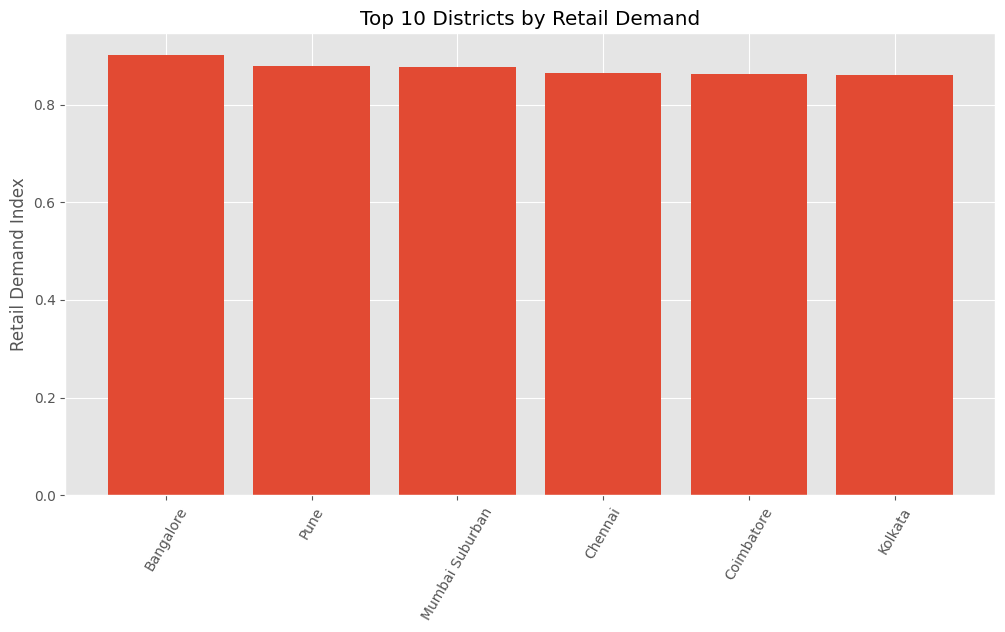

In [ ]:
# Top Retail Markets Chart

plt.figure(figsize=(12,6))

plt.bar(

    top_markets["Name"].head(10),

    top_markets["Retail_Demand_Index"].head(10)

)

plt.xticks(rotation=60)

plt.ylabel("Retail Demand Index")

plt.title("Top 10 Districts by Retail Demand")

plt.show()

In [ ]:
# Save Retail Demand Dataset

districts.to_csv(

    "retail_demand_index.csv",

    index=False

)

print("✅ retail_demand_index.csv created successfully.")

✅ retail_demand_index.csv created successfully.


In [ ]:

# Download Dataset


from google.colab import files

files.download("retail_demand_index.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Visualize Top Retail Demand Districts

import plotly.express as px
import plotly.graph_objects as go

top_demand = (
    districts
    .nlargest(15, "Retail_Demand_Index")
    .sort_values("Retail_Demand_Index")
)

fig = px.bar(
    top_demand,
    x="Retail_Demand_Index",
    y="District",
    orientation="h",
    text="Retail_Demand_Index",
    title="Top 15 Districts by Retail Demand Index",
    hover_data=[
        "TOT_P",
        "No_HH",
        "Literacy_Rate",
        "Workforce_Rate"
    ]
)

fig.update_traces(
    texttemplate="%{text:.3f}",
    textposition="outside"
)

fig.update_layout(
    template="plotly_white",
    height=650,
    xaxis_title="Retail Demand Index",
    yaxis_title="District"
)

fig.show()

In [ ]:
from google.colab import files
import pandas as pd
import io

uploaded = files.upload()

# Automatically read the uploaded CSV
filename = list(uploaded.keys())[0]

stores = pd.read_csv(
    io.BytesIO(uploaded[filename])
)

print("Loaded file:", filename)
print("Shape:", stores.shape)

print("\nColumns:")
print(stores.columns.tolist())

stores.head()

Saving master_darkstores.csv to master_darkstores.csv
Loaded file: master_darkstores.csv
Shape: (4081, 7)

Columns:
['id', 'locality', 'city', 'state', 'latitude', 'longitude', 'brand']


,id,locality,city,state,latitude,longitude,brand
0,42985,NaN,NaN,NaN,8.478260,76.954711,Blinkit
1,40038,NaN,NaN,NaN,8.525199,76.955395,Blinkit
2,38514,NaN,NaN,NaN,9.587031,76.535782,Blinkit
3,38406,NaN,NaN,NaN,9.922391,78.095686,Blinkit
4,39056,NaN,NaN,NaN,9.949993,76.253442,Blinkit


In [ ]:
import plotly.express as px

# Top 30 markets by demand
plot_df = (
    districts
    .sort_values("Retail_Demand_Index", ascending=False)
    .head(30)
    .copy()
)

fig = px.scatter(
    plot_df,

    x="TOT_P",
    y="Retail_Demand_Index",

    size="No_HH",
    color="Workforce_Rate",

    hover_name="Name",

    hover_data={
        "TOT_P": ":,",
        "No_HH": ":,",
        "Literacy_Rate": ":.1f",
        "Workforce_Rate": ":.1f",
        "Retail_Demand_Index": ":.3f"
    },

    color_continuous_scale=[
        "#F8CB46",
        "#FC8019",
        "#7A288A"
    ],

    size_max=50
)

fig.update_layout(

    title=dict(
        text=(
            "<b>Does Population Alone Create Retail Demand?</b><br>"
            "<span style='font-size:13px;color:#777777'>"
            "Comparing population scale with composite retail demand strength"
            "</span>"
        ),
        x=0.5,
        xanchor="center",
        font=dict(size=22)
    ),

    xaxis=dict(
        title="Population →",
        tickformat="~s",
        gridcolor="#EEEEEE"
    ),

    yaxis=dict(
        title="Retail Demand Index →",
        gridcolor="#EEEEEE"
    ),

    coloraxis_colorbar=dict(
        title="Workforce<br>Rate"
    ),

    plot_bgcolor="#FCFCFC",
    paper_bgcolor="white",

    width=1000,
    height=620,

    margin=dict(
        t=120,
        l=90,
        r=120,
        b=80
    )
)

fig.show()

In [ ]:
import plotly.graph_objects as go

# ==========================================
# TOP RETAIL DEMAND MARKETS
# ==========================================

top_rdi = (
    districts[
        [
            "Name",
            "TOT_P",
            "Literacy_Rate",
            "Workforce_Rate",
            "Retail_Demand_Index"
        ]
    ]
    .dropna()

    # Prevent duplicate district names
    .groupby("Name", as_index=False)
    .agg(
        Population=("TOT_P", "max"),
        Literacy=("Literacy_Rate", "mean"),
        Workforce=("Workforce_Rate", "mean"),
        RDI=("Retail_Demand_Index", "max")
    )

    .sort_values("RDI", ascending=False)
    .head(10)
    .sort_values("RDI")
)


# ==========================================
# FIGURE
# ==========================================

fig = go.Figure()

fig.add_trace(
    go.Bar(
        x=top_rdi["RDI"],
        y=top_rdi["Name"],

        orientation="h",

        marker=dict(

            color=top_rdi["RDI"],

            # NEW DEMAND INTELLIGENCE PALETTE
            colorscale=[
                [0.00, "#B8E0D2"],   # soft mint
                [0.35, "#4EA8A8"],   # teal
                [0.70, "#2563A6"],   # blue
                [1.00, "#4338CA"]    # indigo
            ],

            line=dict(
                color="white",
                width=1.5
            )
        ),

        text=[
            f"{x:.3f}"
            for x in top_rdi["RDI"]
        ],

        textposition="outside",

        textfont=dict(
            size=12,
            color="#263B5E"
        ),

        customdata=top_rdi[
            [
                "Population",
                "Literacy",
                "Workforce"
            ]
        ],

        hovertemplate=(
            "<b>%{y}</b><br><br>"
            "Retail Demand Index: %{x:.3f}<br>"
            "Population: %{customdata[0]:,.0f}<br>"
            "Literacy Rate: %{customdata[1]:.1f}%<br>"
            "Workforce Rate: %{customdata[2]:.1f}%"
            "<extra></extra>"
        )
    )
)


# ==========================================
# LAYOUT
# ==========================================

fig.update_layout(

    title=dict(
        text=(
            "<b>INDIA'S STRONGEST RETAIL DEMAND MARKETS</b><br>"
            "<span style='font-size:13px;color:#777777'>"
            "Top districts ranked by combined demographic demand strength"
            "</span>"
        ),

        x=0.5,
        xanchor="center",

        font=dict(
            size=22,
            color="#263B5E"
        )
    ),

    xaxis=dict(
        title="Retail Demand Index →",

        range=[
            max(0, top_rdi["RDI"].min() - 0.015),
            top_rdi["RDI"].max() + 0.025
        ],

        gridcolor="#E8EDF2",
        zeroline=False,

        tickfont=dict(
            color="#53657A"
        )
    ),

    yaxis=dict(
        title="",
        showgrid=False,

        tickfont=dict(
            size=12,
            color="#263B5E"
        )
    ),

    plot_bgcolor="#FAFCFD",
    paper_bgcolor="white",

    showlegend=False,

    width=1000,
    height=600,

    bargap=0.30,

    margin=dict(
        t=125,
        l=170,
        r=100,
        b=80
    )
)

fig.show()